Churned: 1,307 (33.3%)
Active:  2,613 (66.7%)


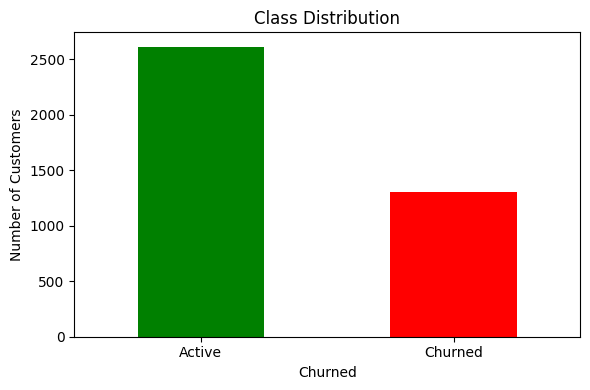


Imbalance ratio: 2.0:1


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

customers = pd.read_csv('../data/processed/customer_features.csv')

churn_rate = customers['Churned'].mean()
print(f"Churned: {customers['Churned'].sum():,} ({churn_rate:.1%})")
print(f"Active:  {(customers['Churned']==0).sum():,} ({1-churn_rate:.1%})")

# Plot class distribution
plt.figure(figsize=(6, 4))
customers['Churned'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.xticks([0, 1], ['Active', 'Churned'], rotation=0)
plt.title('Class Distribution')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

# Imbalance ratio
print(f"\nImbalance ratio: {(customers['Churned']==0).sum() / customers['Churned'].sum():.1f}:1")

## Observations — Class Imbalance

**Is the dataset imbalanced?**

Yes. Out of 3,920 customers, 1,307 (33.3%) are labeled as churned and 2,613 (66.7%) 
are active — a 2.0:1 imbalance ratio. This isn't an extreme imbalance (like 95:5), 
but it's significant enough that it needs to be accounted for during modeling.

**Why does this matter for a model optimizing for accuracy?**

If a model simply predicted "Active" for every single customer, it would be correct 
66.7% of the time without learning any actual pattern in the data. That accuracy 
score would look reasonable at a glance, but the model would be completely useless 
for the business goal — it would never flag a single at-risk customer.

This is the core reason accuracy is the wrong metric to optimize for here. Instead, 
the evaluation framework in this project prioritizes:
- **Precision** — when the model predicts churn, how often is it correct?
- **Recall** — of all customers who actually churned, how many did the model catch?
- **PR-AUC** — a threshold-independent summary of precision/recall tradeoff, which 
  is more informative than ROC-AUC on imbalanced data because it focuses on 
  performance on the minority (churned) class specifically.

**What this means going into modeling**

The 2:1 ratio means class imbalance handling (via `scale_pos_weight` or SMOTE, 
covered in Day 3) is worth testing, though the imbalance isn't severe enough that 
the model will completely ignore the minority class without it — it's a moderate 
case, not an extreme one.